## **Project Overview** ##
---
This project analyzes card transaction data to identify potentially suspicious accounts in the absence of an explicit fraud or default label.

The workflow includes:
1. initial data inspection and quality checks,
2. exploratory data analysis of key transaction and behavioral features,
3. feature engineering and aggregation from transaction level to account level,
4. proxy target construction using unsupervised anomaly detection,
5. development of an interpretable baseline model (Logistic Regression with WOE),
6. comparison with alternative machine learning approaches (CatBoost, XGBoost, Random Forest)
7. evaluation of model performance and discussion of interpretability vs. accuracy trade-offs.

## DATA

The dataset consists of card transaction records, where each row corresponds to a single transaction.
It includes numerical, categorical, and temporal features describing transaction behavior, account activity, and technical attributes.

In [38]:
import pandas as pd
import numpy as np

In [39]:
df = pd.read_csv("bank_transactions_data_2.csv")

In [40]:
date_cols = ["TransactionDate", "PreviousTransactionDate"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")


df["TransactionAmount"] = df["TransactionAmount"].astype(float)
df["AccountBalance"] = df["AccountBalance"].astype(float)
df["CustomerAge"] = pd.to_numeric(df["CustomerAge"], errors="coerce")
df["TransactionDuration"] = pd.to_numeric(df["TransactionDuration"], errors="coerce")
df["LoginAttempts"] = pd.to_numeric(df["LoginAttempts"], errors="coerce")

In [41]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [42]:
data_overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
}).sort_values("missing_%", ascending=False)

data_overview

,dtype,missing_%,n_unique
TransactionID,object,0.0,2512
AccountID,object,0.0,495
TransactionAmount,float64,0.0,2455
TransactionDate,datetime64[ns],0.0,2512
TransactionType,object,0.0,2
Location,object,0.0,43
DeviceID,object,0.0,681
IP Address,object,0.0,592
MerchantID,object,0.0,100
Channel,object,0.0,3


**Data Types**
1. Numerical features (`TransactionAmount`, `AccountBalance`, `TransactionDuration`, `LoginAttempts`, `CustomerAge`, etc.)
2. Categorical features (`TransactionType`, `Channel`, `Location`, `MerchantID`, `DeviceID`)
3. Temporal features (`TransactionDate`, `PreviousTransactionDate`)


The dataset represents realistic transactional behavior with right-skewed distributions and heterogeneous account activity.
No severe data quality issues were identified.
These observations justify further feature engineering and aggregation at the account level.

## EDA



Before exploratory data analysis, basic data preparation steps were performed.
This included type conversion for numerical and temporal features, as well as a high-level overview of data structure, missing values, and feature types.

In [43]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def num(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return s.dropna()

def hist_box(x, name, bins=50, log=False):
    x = num(x)
    if log:
        x = x[x > 0]
        x_plot = np.log1p(x)
        xlab = "log1p(value)"
        title_suffix = " (log1p)"
    else:
        x_plot = x
        xlab = "value"
        title_suffix = ""
    plt.figure(figsize=(8, 4))
    plt.hist(x_plot, bins=bins)
    plt.title(f"{name} distribution{title_suffix}")
    plt.xlabel(xlab); plt.ylabel("count")
    plt.grid(True, alpha=0.2)
    plt.show()
    plt.figure(figsize=(8, 1.8))
    plt.boxplot(x_plot, vert=False)
    plt.title(f"{name} boxplot{title_suffix}")
    plt.xlabel(xlab)
    plt.grid(True, axis="x", alpha=0.2)
    plt.show()
    return x

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
df["Hour"] = df["TransactionDate"].dt.hour
df["IsNight"] = df["Hour"].between(0, 5).astype(int)


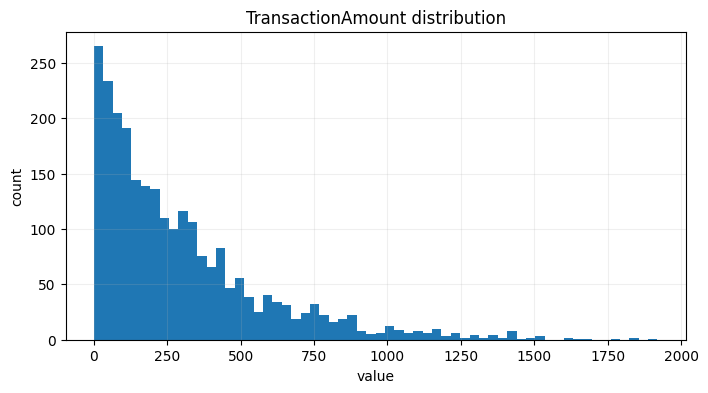

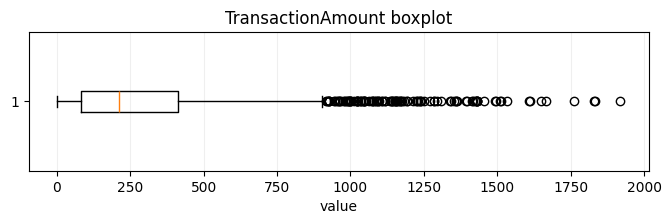

In [44]:
x = hist_box(df["TransactionAmount"], "TransactionAmount", bins=60, log=False)


**Findings (TransactionAmount):**
1. The distribution is right-skewed, which is typical for transaction-level monetary values.
2. Basic quality checks: min = 0.26, max = 1919.
3. All values are positive; there are no zero or negative amounts, indicating the feature is consistent and valid.

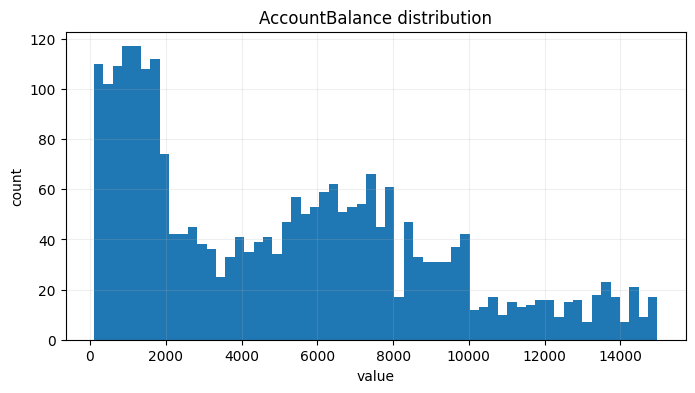

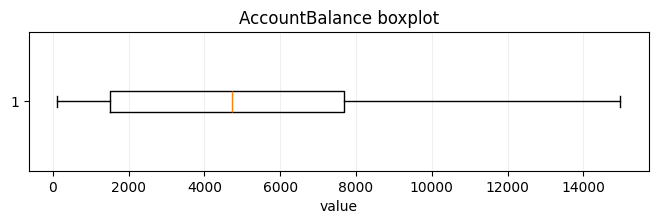

In [45]:
x = hist_box(df["AccountBalance"], "AccountBalance", bins=60, log=False)


**Findings (AccountBalance):**
1. The distribution shows a wide range with a right tail, which is expected for account balances.
2. Basic quality checks: min = 101, max = 14,978.
3. No negative values are present, and no extreme outliers are observed, indicating that the feature is valid and reliable.

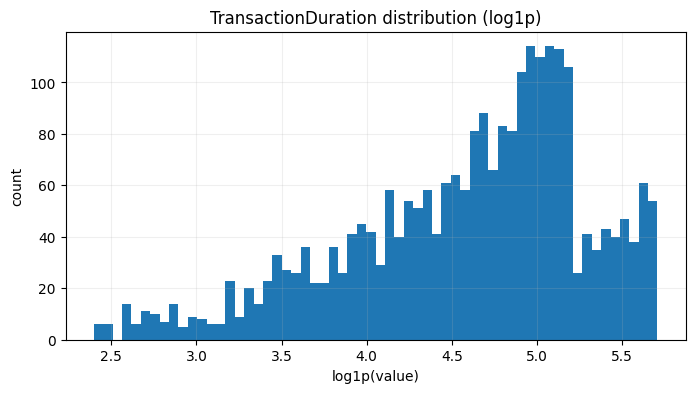

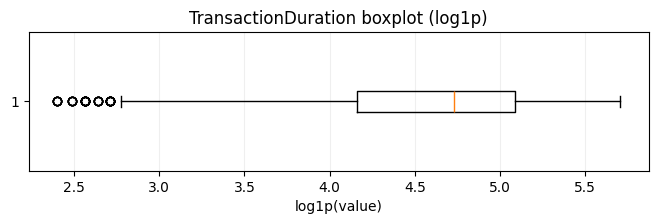

In [46]:

x = num(df["TransactionDuration"])
x = hist_box(df["TransactionDuration"], "TransactionDuration", bins=60, log=True)


**Findings (TransactionDuration):**
1. In the log scale, the distribution shows moderate variability without abnormal spikes.
2. Basic quality checks: min = 10, max = 300.
3. No zero values are present, and the range appears realistic, suggesting no evident logging errors.

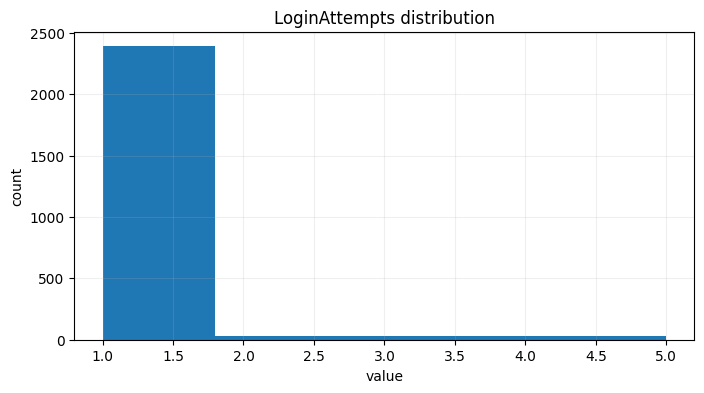

In [47]:
x = num(df["LoginAttempts"])
plt.figure(figsize=(8,4))
plt.hist(x, bins=int(min(10, x.nunique())))
plt.title("LoginAttempts distribution")
plt.xlabel("value"); plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.show()


**Findings (LoginAttempts):**
1. The distribution peaks at a single login attempt, with rare values between 2 and 5, which is expected behavior.
2. Basic quality checks: min = 1, max = 5, 95th percentile = 1.
3. The small right tail may serve as a useful signal for identifying potentially suspicious accounts.

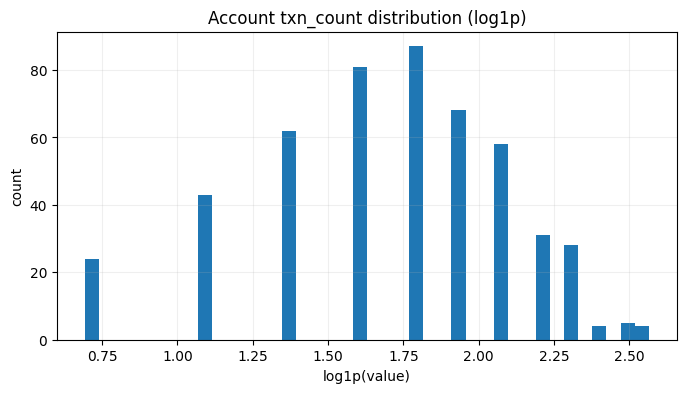

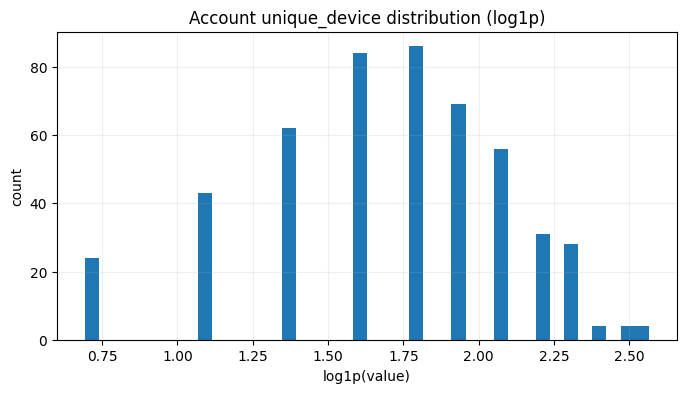

In [48]:
acc = (df.groupby("AccountID")
         .agg(txn_count=("TransactionID","count"),
              unique_device=("DeviceID","nunique"),
              unique_merchant=("MerchantID","nunique"))
         .reset_index())

x = acc["txn_count"]
plt.figure(figsize=(8,4))
plt.hist(np.log1p(x), bins=40)
plt.title("Account txn_count distribution (log1p)")
plt.xlabel("log1p(value)"); plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.show()

x = acc["unique_device"]
plt.figure(figsize=(8,4))
plt.hist(np.log1p(x), bins=40)
plt.title("Account unique_device distribution (log1p)")
plt.xlabel("log1p(value)"); plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.show()

**Findings (Transactions per Account):**
1. The distribution has a right tail, indicating a small number of highly active accounts.
2. Basic checks: min = 1, max = 12, 95th percentile = 9.
3. Highly active accounts may be associated with anomalous or suspicious behavior.


**Findings (Unique Devices per Account):**
1. Most accounts use 1–2 devices, while the right tail indicates potentially suspicious cases.
2. Basic checks: min = 1, max = 12, 95th percentile = 9.
3. This feature is well suited for anomaly detection and suspicious behavior scoring.

## FEATURES

Feature engineering focuses on capturing transactional intensity, behavioral stability, and account-level heterogeneity.

In [49]:
df["TimeSincePrevTransaction"] = (
    df["TransactionDate"] - df["PreviousTransactionDate"]).dt.total_seconds()
df["TimeSincePrevTransaction"] = df["TimeSincePrevTransaction"].fillna(0)

In [50]:
df["AmountToBalanceRatio"] = df["TransactionAmount"] / (df["AccountBalance"] + 1)

In [51]:
df["Hour"] = df["TransactionDate"].dt.hour
df["DayOfWeek"] = df["TransactionDate"].dt.dayofweek

In [52]:
df["IsNight"] = ((df["Hour"] >= 23) | (df["Hour"] <= 6)).astype(int)

In [53]:
df = df.sort_values(["AccountID", "TransactionDate"])

In [54]:
df["IP_changed"] = (
    df.groupby("AccountID")["IP Address"]
      .transform(lambda x: x != x.shift())
      .astype(int))

In [55]:
df["Device_changed"] = (
    df.groupby("AccountID")["DeviceID"]
      .transform(lambda x: x != x.shift())
      .astype(int))

## ACC INFO

In [56]:
agg_num = df.groupby("AccountID").agg(
    mean_amount=("TransactionAmount", "mean"),
    median_amount=("TransactionAmount", "median"),
    std_amount=("TransactionAmount", "std"),
    max_amount=("TransactionAmount", "max"),
    min_amount=("TransactionAmount", "min"),
    avg_balance=("AccountBalance", "mean"),)

In [57]:
agg_behavior = df.groupby("AccountID").agg(
    txn_count=("TransactionID", "count"),
    debit_count=("TransactionType", lambda x: (x == "Debit").sum()),
    credit_count=("TransactionType", lambda x: (x == "Credit").sum()),
    night_txn_ratio=("IsNight", "mean"),)


agg_behavior["debit_ratio"] = agg_behavior["debit_count"] / agg_behavior["txn_count"]
agg_behavior["credit_ratio"] = agg_behavior["credit_count"] / agg_behavior["txn_count"]


In [58]:
agg_time = df.groupby("AccountID").agg(
    avg_time_between=("TimeSincePrevTransaction", "mean"),
    std_time_between=("TimeSincePrevTransaction", "std"),)

In [59]:
unique_ip = df.groupby("AccountID")["IP Address"].nunique().rename("unique_ip")
unique_devices = df.groupby("AccountID")["DeviceID"].nunique().rename("unique_devices")
unique_locations = df.groupby("AccountID")["Location"].nunique().rename("unique_locations")
unique_merchants = df.groupby("AccountID")["MerchantID"].nunique().rename("unique_merchants")

In [60]:
login_stats = df.groupby("AccountID")["LoginAttempts"].mean().rename("avg_login_attempts")

## PROFILE CREATE

In [61]:
profile = (
    agg_num
    .join(agg_behavior)
    .join(agg_time)
    .join(unique_ip)
    .join(unique_devices)
    .join(unique_locations)
    .join(unique_merchants)
    .join(login_stats))


profile = profile.reset_index()

In [62]:
profile.to_csv("client_profile.csv", index=False)


print(profile.shape)

(495, 20)


In [63]:
profile.head()

,AccountID,mean_amount,median_amount,std_amount,max_amount,min_amount,avg_balance,txn_count,debit_count,credit_count,night_txn_ratio,debit_ratio,credit_ratio,avg_time_between,std_time_between,unique_ip,unique_devices,unique_locations,unique_merchants,avg_login_attempts
0,AC00001,130.380000,130.38,116.799898,212.97,47.79,2915.160000,2,2,0,0.0,1.000000,0.000000,-3.331877e+07,3.665533e+06,2,2,2,2,1.000000
1,AC00002,293.744286,331.66,195.695091,516.47,12.62,4480.421429,7,6,1,0.0,0.857143,0.142857,-4.408286e+07,1.018210e+07,7,7,7,6,1.142857
2,AC00003,253.268000,237.97,158.484753,416.62,20.17,7329.568000,5,4,1,0.0,0.800000,0.200000,-4.980202e+07,9.750803e+06,5,5,5,5,1.000000
3,AC00004,242.231111,136.31,231.081586,642.54,13.16,3340.956667,9,8,1,0.0,0.888889,0.111111,-3.666893e+07,8.210281e+06,9,9,9,9,1.000000
4,AC00005,347.974444,377.92,189.487268,680.76,107.48,4457.837778,9,8,1,0.0,0.888889,0.111111,-4.228421e+07,1.050646e+07,9,9,9,9,1.000000


## ANOMALIES

In [64]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

id_col = "AccountID"
X = profile.drop(columns=[id_col]).copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[num_cols].copy()

prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

X_prep = prep.fit_transform(X_num)


cont = 0.05
iso = IsolationForest(
    n_estimators=600,
    contamination=cont,
    random_state=42
)
iso.fit(X_prep)


iso_pred = iso.predict(X_prep)
iso_score = iso.decision_function(X_prep)

profile["anomaly_iforest"] = (iso_pred == -1).astype(int)
profile["iforest_score"] = iso_score

print("Доля аномалий IsolationForest:", profile["anomaly_iforest"].mean())

lof = LocalOutlierFactor(
    n_neighbors=25,
    contamination=cont
)
lof_pred = lof.fit_predict(X_prep)
profile["anomaly_lof"] = (lof_pred == -1).astype(int)

print("Доля аномалий LOF:", profile["anomaly_lof"].mean())


profile["target"] = profile["anomaly_iforest"]


print("доля target=1:", profile["target"].mean())

Доля аномалий IsolationForest: 0.050505050505050504
Доля аномалий LOF: 0.050505050505050504
доля target=1: 0.050505050505050504


## TRAIN TEST SPLIT

In [65]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    profile.index,
    test_size=0.3,
    random_state=42,
    stratify=profile["target"]
)

train = profile.loc[train_idx].reset_index(drop=True)
test  = profile.loc[test_idx].reset_index(drop=True)

print("Train target rate:", train["target"].mean())
print("Test  target rate:", test["target"].mean())

Train target rate: 0.049132947976878616
Test  target rate: 0.053691275167785234


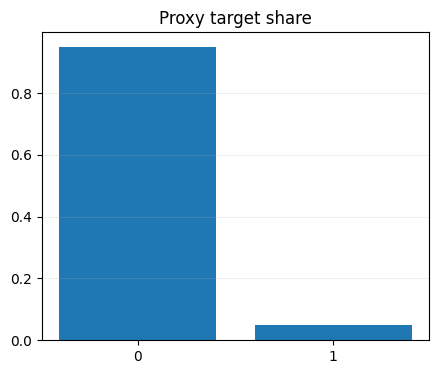

In [66]:
share = profile["target"].value_counts(normalize=True).sort_index()
plt.figure(figsize=(5,4))
plt.bar(["0","1"], share.values)
plt.title("Proxy target share")
plt.grid(alpha=0.2, axis="y")
plt.show()

## BASELINE(LR + WOE)

In [67]:
exclude_cols = {
    "AccountID",
    "target",
    "anomaly_iforest",
    "anomaly_lof",
    "iforest_score"
}

features = [
    c for c in train.columns
    if c not in exclude_cols and np.issubdtype(train[c].dtype, np.number)
]


def woe_iv(df, feature, target="target", eps=1e-6):

    tab = df.groupby(feature)[target].agg(["count", "sum"])
    tab.columns = ["total", "bad"]
    tab["good"] = tab["total"] - tab["bad"]

    bad_total = tab["bad"].sum()
    good_total = tab["good"].sum()

    tab["dist_bad"] = tab["bad"] / (bad_total + eps)
    tab["dist_good"] = tab["good"] / (good_total + eps)

    tab["woe"] = np.log((tab["dist_good"] + eps) / (tab["dist_bad"] + eps))
    tab["iv"] = (tab["dist_good"] - tab["dist_bad"]) * tab["woe"]

    return tab.reset_index(), tab["iv"].sum()


woe_train = pd.DataFrame()
woe_test  = pd.DataFrame()

woe_train["target"] = train["target"]
woe_test["target"]  = test["target"]

iv_list = []

for col in features:


    train_bins = pd.qcut(train[col], q=10, duplicates="drop")
    test_bins  = pd.cut(test[col], bins=train_bins.cat.categories)


    tmp = train.copy()
    tmp["bin"] = train_bins.astype(str)

    woe_table, iv = woe_iv(tmp, "bin", target="target")
    woe_map = dict(zip(woe_table["bin"], woe_table["woe"]))


    woe_train[col + "_woe"] = train_bins.astype(str).map(woe_map)
    woe_test[col + "_woe"]  = test_bins.astype(str).map(woe_map)

    iv_list.append((col, iv))


woe_train = woe_train.fillna(0)
woe_test  = woe_test.fillna(0)
iv_report = pd.DataFrame(iv_list, columns=["feature", "IV"]).sort_values("IV", ascending=False)
iv_report


,feature,IV
16,unique_locations,8.792012e+00
14,unique_ip,8.412523e+00
17,unique_merchants,8.380203e+00
15,unique_devices,8.337416e+00
6,txn_count,8.297500e+00
7,debit_count,7.924586e+00
3,max_amount,5.421108e+00
0,mean_amount,4.193137e+00
4,min_amount,3.980293e+00
2,std_amount,3.784659e+00


## METRICS

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve


X_train = woe_train.drop(columns=["target"])
y_train = woe_train["target"]

X_test  = woe_test.drop(columns=["target"])
y_test  = woe_test["target"]


logreg = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000
)

logreg.fit(X_train, y_train)


train_pred = logreg.predict_proba(X_train)[:, 1]
test_pred  = logreg.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
lr_test_auc  = roc_auc_score(y_test, test_pred)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {lr_test_auc:.4f}")


def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)

ks_train = ks_statistic(y_train, train_pred)
lr_test_ks  = ks_statistic(y_test, test_pred)

print(f"Train KS: {ks_train:.4f}")
print(f"Test  KS: {lr_test_ks:.4f}")


coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coef": logreg.coef_[0]
}).sort_values("coef", ascending=False)

coef_table


Train ROC-AUC: 0.9961
Test  ROC-AUC: 0.9220
Train KS: 0.9787
Test  KS: 0.7686


,feature,coef
13,std_time_between_woe,1.648475e-01
6,txn_count_woe,1.156365e-01
15,unique_devices_woe,8.108346e-02
9,night_txn_ratio_woe,-2.007327e-08
14,unique_ip_woe,-3.753769e-03
12,avg_time_between_woe,-1.719462e-02
2,std_amount_woe,-1.676446e-01
7,debit_count_woe,-1.956696e-01
17,unique_merchants_woe,-2.017253e-01
5,avg_balance_woe,-2.353373e-01


In [69]:
!pip install catboost xgboost


## MODELS

In [70]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

exclude_cols = {"AccountID","target","anomaly_iforest","anomaly_lof","iforest_score"}
features = [c for c in profile.columns
            if c not in exclude_cols and np.issubdtype(profile[c].dtype, np.number)]

X_train_raw = train[features]
y_train_raw = train["target"]
X_test_raw  = test[features]
y_test_raw  = test["target"]



# CatBoost

cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

cb.fit(X_train_raw, y_train_raw)
cb_train_pred = cb.predict_proba(X_train_raw)[:, 1]
cb_test_pred  = cb.predict_proba(X_test_raw)[:, 1]

cb_train_auc = roc_auc_score(y_train_raw, cb_train_pred)
cb_test_auc  = roc_auc_score(y_test_raw, cb_test_pred)

cb_train_ks = ks_statistic(y_train_raw, cb_train_pred)
cb_test_ks  = ks_statistic(y_test_raw, cb_test_pred)


# XGBoost

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_raw, y_train_raw)
xgb_train_pred = xgb.predict_proba(X_train_raw)[:, 1]
xgb_test_pred  = xgb.predict_proba(X_test_raw)[:, 1]

xgb_train_auc = roc_auc_score(y_train_raw, xgb_train_pred)
xgb_test_auc  = roc_auc_score(y_test_raw, xgb_test_pred)

xgb_train_ks = ks_statistic(y_train_raw, xgb_train_pred)
xgb_test_ks  = ks_statistic(y_test_raw, xgb_test_pred)

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_raw, y_train_raw)

rf_train_pred = rf.predict_proba(X_train_raw)[:, 1]
rf_test_pred  = rf.predict_proba(X_test_raw)[:, 1]

rf_train_auc = roc_auc_score(y_train_raw, rf_train_pred)
rf_test_auc  = roc_auc_score(y_test_raw, rf_test_pred)

rf_train_ks = ks_statistic(y_train_raw, rf_train_pred)
rf_test_ks  = ks_statistic(y_test_raw, rf_test_pred)


## Data quality / cleaning notes

In [71]:

dq = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
}).sort_values("missing_%", ascending=False)

display(dq)


,dtype,missing_%,n_unique
TransactionID,object,0.0,2512
AccountID,object,0.0,495
TransactionAmount,float64,0.0,2455
TransactionDate,datetime64[ns],0.0,2512
TransactionType,object,0.0,2
Location,object,0.0,43
DeviceID,object,0.0,681
IP Address,object,0.0,592
MerchantID,object,0.0,100
Channel,object,0.0,3


In [72]:

missing = dq[dq["missing_%"] > 0]
display(missing)


,dtype,missing_%,n_unique


**Missing values**
1. No missing values were observed.

**Outliers**
1. Key numerical features (transaction amounts, balances, durations, counters) exhibit right-skewed distributions,
  which is typical for transactional and behavioral data.
2. Extreme values are interpreted as potentially informative signals,
  therefore aggressive filtering or removal of outliers was not applied.
3. In the scoring stage, outliers are handled through binning and WOE transformation.

In [73]:
leakage_cols = [
    "iforest_score",
    "anomaly_iforest",
    "anomaly_lof",
    "anomaly_flag",
    "anomaly_score"
]

present_leakage = [c for c in leakage_cols if c in df.columns]
display(present_leakage)


[]

**Data Leakage Control**
1. Features directly related to the construction of the proxy target (anomaly detection scores and flags)
  were not used when training supervised models.
2. This ensures that the models do not leak information from the target and are evaluated correctly.
3. Potential leakage features (e.g., `iforest_score`, anomaly flags) are absent from the training dataset.

## Model comparison table

In [74]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (WOE)",
        "CatBoost",
        "XGBoost",
        "Random Forest"
    ],
    "ROC-AUC (test)": [
        lr_test_auc,
        cb_test_auc,
        xgb_test_auc,
        rf_test_auc
    ],
    "KS (test)": [
        lr_test_ks,
        cb_test_ks,
        xgb_test_ks,
        rf_test_ks
    ],
    "Interpretability": [
        "High (WOE, coefficients)",
        "Medium",
        "Medium",
        "Medium"
    ]
}).round(4)
display(Markdown("## Model comparison"))
display(model_comparison)

## Model comparison

,Model,ROC-AUC (test),KS (test),Interpretability
0,Logistic Regression (WOE),0.9220,0.7686,"High (WOE, coefficients)"
1,CatBoost,0.9982,0.9929,Medium
2,XGBoost,0.9965,0.9858,Medium
3,Random Forest,0.9947,0.9929,Medium


**Model Comparison Conclusions**

1. Logistic Regression with WOE demonstrates strong and stable performance (ROC-AUC = 0.92, KS = 0.77)
  while maintaining high interpretability, which makes it well suited for classical credit scoring tasks.
2. CatBoost and XGBoost achieve substantially higher performance metrics,
  but are less interpretable compared to logistic regression.
3. Random Forest provides competitive results and confirms the robustness of the engineered features,
  but does not outperform boosting models in terms of predictive quality.
4. The very high ROC-AUC and KS values of the tree-based ensemble models are partly explained by the fact
  that they approximate the proxy target generated via unsupervised anomaly detection.
5. Therefore, model selection depends on the objective:
  interpretable and transparent scoring (LogReg + WOE) versus maximum detection performance
  for identifying suspicious accounts (CatBoost / XGBoost).

## Conclusion

This project addresses the problem of identifying suspicious accounts based on transactional data in the absence of a true fraud or default label.
Raw transaction-level data were aggregated to the account level, which made it possible to capture customer behavioral patterns and bring the task closer to real-world credit scoring and fraud detection scenarios.
Since no ground-truth target variable was available, a proxy target was constructed using unsupervised anomaly detection (Isolation Forest), with the share of anomalous accounts fixed at approximately 5%.

As an interpretable baseline, a logistic regression model with WOE-transformed features was built and demonstrated stable performance on the test set (ROC-AUC = 0.92, KS = 0.77).
This approach aligns with classical credit scoring requirements and allows for transparent interpretation of feature contributions to risk.
As alternative approaches, CatBoost, XGBoost, and Random Forest models were applied.
Tree-based ensemble models achieved substantially higher performance metrics, confirming the strong predictive power of the engineered behavioral features.
Random Forest demonstrated competitive results and served as an additional validation of feature robustness, although it did not outperform gradient boosting methods.

Overall, the project clearly illustrates the trade-off between interpretability and predictive performance:
logistic regression with WOE is well suited for transparent and explainable scoring,
while ensemble models—especially boosting techniques—provide maximum effectiveness in detecting suspicious accounts when predictive accuracy is the primary objective.